In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
from prophet import Prophet
from darts.models import VARIMA
from pmdarima import auto_arima
from darts.models import Croston
from darts import TimeSeries

In [5]:
df = pd.read_excel('../data/merged_data_with_safety.xlsx')
df

,year,month,day,white,black,total,date,white_safety,black_safety,total_safety,white_with_safety,black_with_safety,total_with_safety
0,2023,8,1,8.0,1.0,9.0,2023-08-01,0,0,0,8.0,1.0,9.0
1,2023,8,2,13.0,1.0,14.0,2023-08-02,8,1,9,21.0,2.0,23.0
2,2023,8,3,10.0,0.0,10.0,2023-08-03,10,1,12,20.0,1.0,22.0
3,2023,8,4,14.0,0.0,14.0,2023-08-04,10,1,11,24.0,1.0,25.0
4,2023,8,5,0.0,0.0,0.0,2023-08-05,12,0,13,12.0,0.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2025,2,24,2.0,23.0,25.0,2025-02-24,0,4,4,2.0,27.0,29.0
605,2025,2,25,2.0,11.0,13.0,2025-02-25,1,8,8,3.0,19.0,21.0
606,2025,2,26,0.0,6.0,6.0,2025-02-26,1,11,13,1.0,17.0,19.0
607,2025,2,27,0.0,4.0,4.0,2025-02-27,1,13,15,1.0,17.0,19.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               609 non-null    int64         
 1   month              609 non-null    int64         
 2   day                609 non-null    int64         
 3   white              578 non-null    float64       
 4   black              577 non-null    float64       
 5   total              578 non-null    float64       
 6   date               609 non-null    datetime64[ns]
 7   white_safety       609 non-null    int64         
 8   black_safety       609 non-null    int64         
 9   total_safety       609 non-null    int64         
 10  white_with_safety  578 non-null    float64       
 11  black_with_safety  577 non-null    float64       
 12  total_with_safety  578 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(6)
memory usage: 62.0 KB


# EDA

In [11]:
def plot_separate_time_series(df, cols):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(4, 1, i)
        plt.plot(df['date'], df[col], label=col, color='tab:blue')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title(f'{col} over time')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

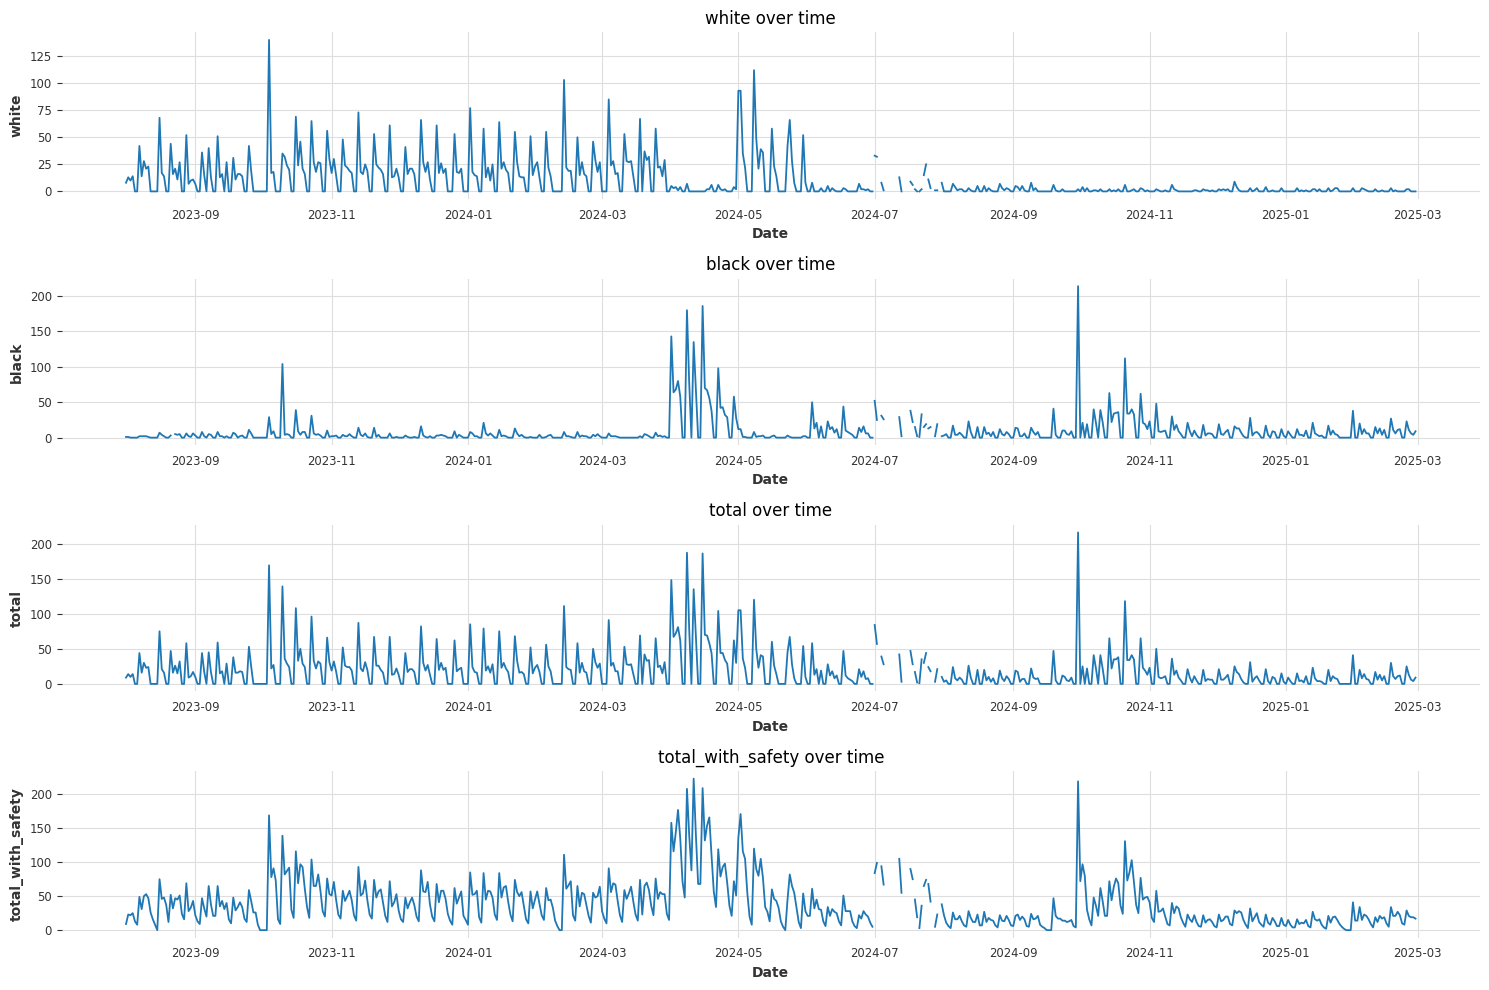

In [12]:
# 실행
plot_separate_time_series(df, ['white', 'black', 'total', 'total_with_safety'])


# 1. Auto_ARIMA
- ARIMA 모델의 최적의 (p, d, q) 조합을 자동으로 찾아주는 함수

> 1. 차분 횟수 d를 테스트로 먼저 결정하고: ADF 테스트 (Augmented Dickey-Fuller Test) 또는 KPSS 테스트로 시계열이 정상인지 확인
2. 주어진 p, q 범위에서 가능한 조합을 시도해서
3. 각 (p, d, q) 조합으로 모델을 학습한 뒤, 가장 AIC(Akaike Information Criterion)/BIC(Bayesian Information Criterion)가 낮은 모델을 고름

In [17]:
def predict_and_plot(df, col, test_ratio=0.2):
    df = df.set_index('date')
    series = df[col]

     # ✅ 결측치를 0으로 채움 (간헐적 수요 유지)
    series = series.fillna(0)
    
    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # 모델 학습
    model = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
    forecast = model.predict(n_periods=len(test))

    # (p,d,q) 출력
    print(f"[{col}] Selected ARIMA Order: {model.order}")

    # 시각화 (예측값과 실제 test 값만 표시)
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='black')
    plt.plot(test.index, forecast, label='Forecast', color='red')
    plt.title(f'{col} - Test vs Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprec

[white] Selected ARIMA Order: (5, 1, 3)


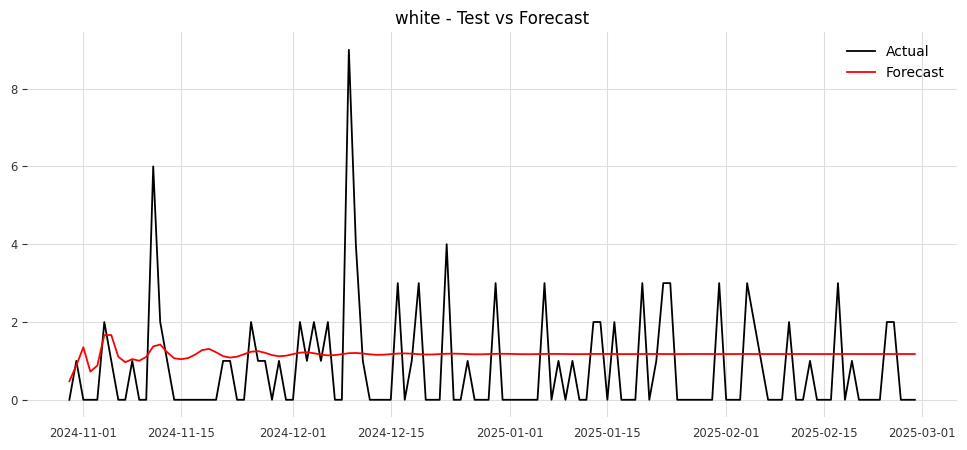

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprec

[black] Selected ARIMA Order: (2, 1, 3)


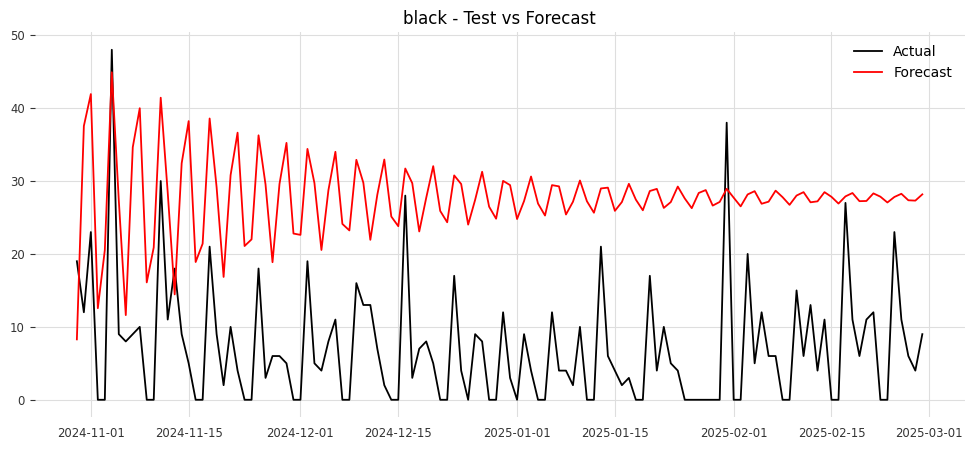

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprec

[total] Selected ARIMA Order: (5, 1, 5)


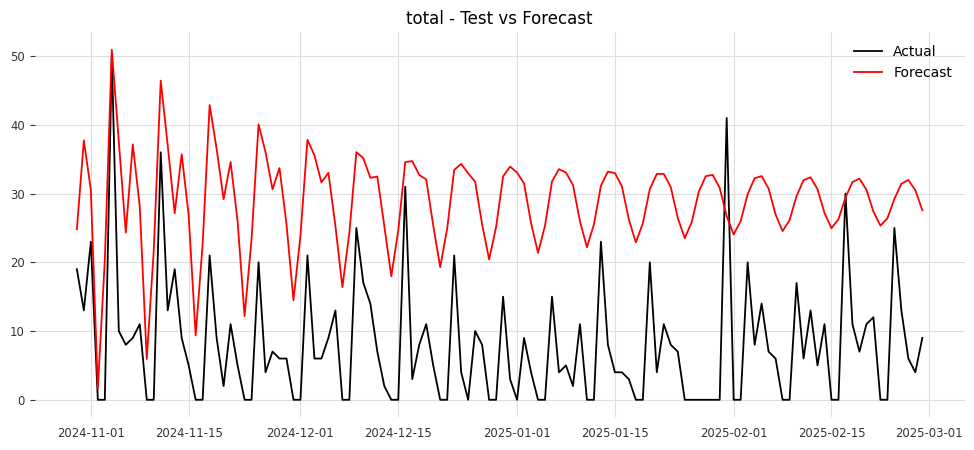

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprec

[total_with_safety] Selected ARIMA Order: (5, 1, 3)


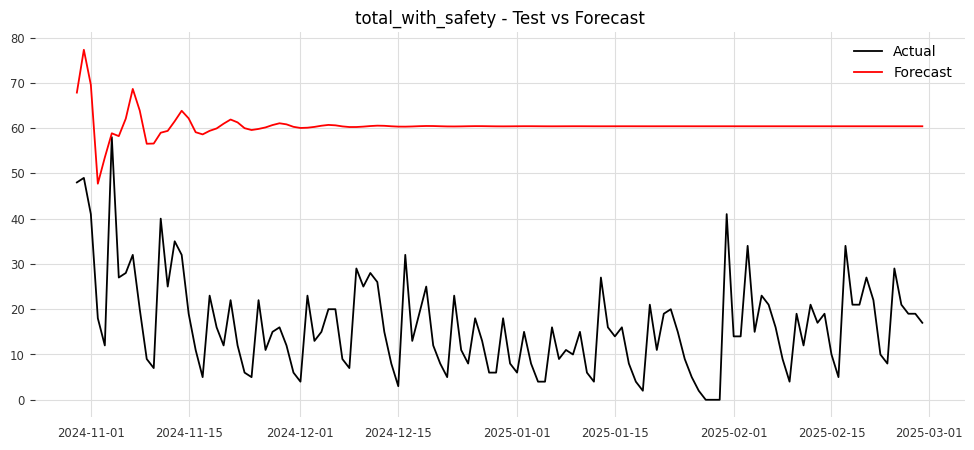

In [18]:
# 대상 컬럼별 반복 예측
target_cols = ['white', 'black', 'total', 'total_with_safety']
for col in target_cols:
    predict_and_plot(df.copy(), col)

# 2. Prophet
- Prophet은 NaN 값을 허용하지 않기 때문에, 예측 전에 반드시 fillna(0) 처리
- 그래야 간헐적 수요에서의 "수요 없음" 상황을 정확하게 반영

In [19]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['date', col]].copy()
    series.columns = ['ds', 'y']  # Prophet에 맞는 컬럼명

    # ✅ 결측치 0으로 채움 (간헐적 수요 반영)
    series['y'] = series['y'].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # Prophet 모델 학습
    model = Prophet()
    model.fit(train)

    # 미래 데이터프레임 생성
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    # 예측값 추출
    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast', color='red')
    plt.title(f'{col} - Prophet Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

16:31:40 - cmdstanpy - INFO - Chain [1] start processing
16:31:40 - cmdstanpy - INFO - Chain [1] done processing


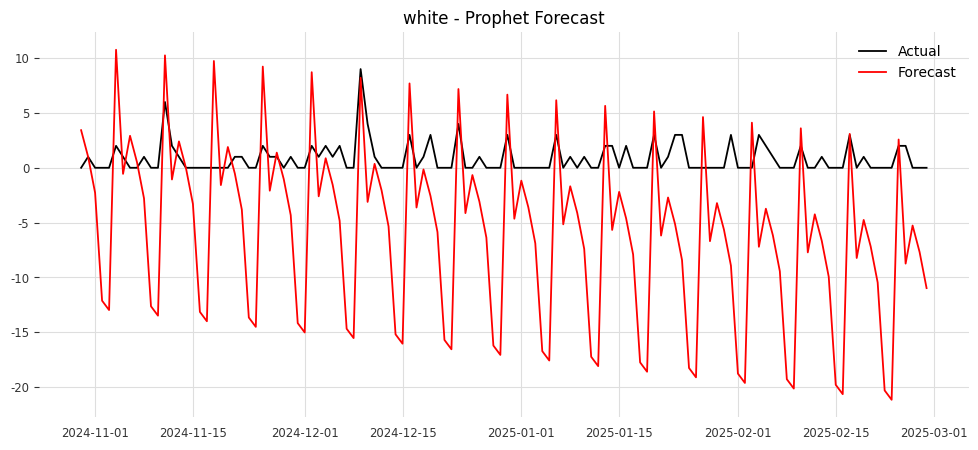

16:31:41 - cmdstanpy - INFO - Chain [1] start processing
16:31:41 - cmdstanpy - INFO - Chain [1] done processing


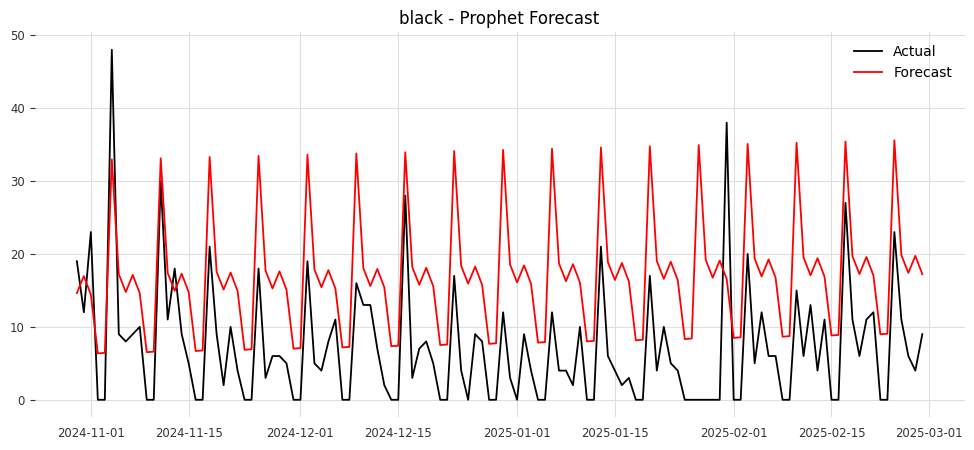

16:31:41 - cmdstanpy - INFO - Chain [1] start processing
16:31:41 - cmdstanpy - INFO - Chain [1] done processing


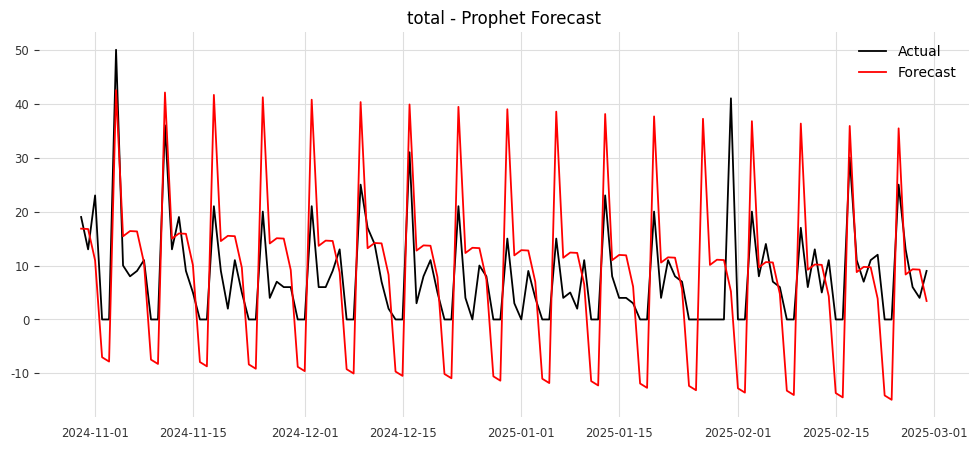

16:31:42 - cmdstanpy - INFO - Chain [1] start processing
16:31:42 - cmdstanpy - INFO - Chain [1] done processing


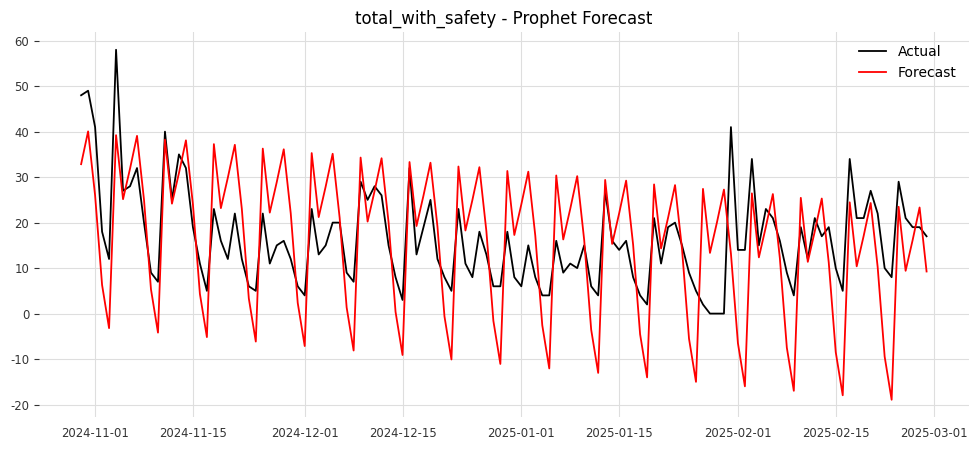

In [20]:
# 실행
target_cols = ['white', 'black', 'total', 'total_with_safety']
for col in target_cols:
    prophet_forecast(df.copy(), col)

# 3. Croston

In [28]:
def croston_forecast(df, col, test_ratio=0.2):
    # ✅ 중복 날짜를 평균으로 집계 + 결측치 0으로 대체
    series = (
        df[['date', col]]
        .groupby('date', as_index=False)
        .mean()
        .fillna({col: 0})
    )

    # TimeSeries 생성
    ts = TimeSeries.from_dataframe(
        series,
        time_col='date',
        value_cols=col,
        fill_missing_dates=True,
        freq='D'
    )

    # Train/Test split
    split_idx = int(len(ts) * (1 - test_ratio))
    train, test = ts[:split_idx], ts[split_idx:]

    # Croston 모델 학습 및 예측
    model = Croston()
    model.fit(train)
    forecast = model.predict(len(test))

    # 시각화
    plt.figure(figsize=(12, 5))
    test.plot(label='Actual', color='black')
    forecast.plot(label='Forecast', color='red')
    plt.title(f'{col} - Croston Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

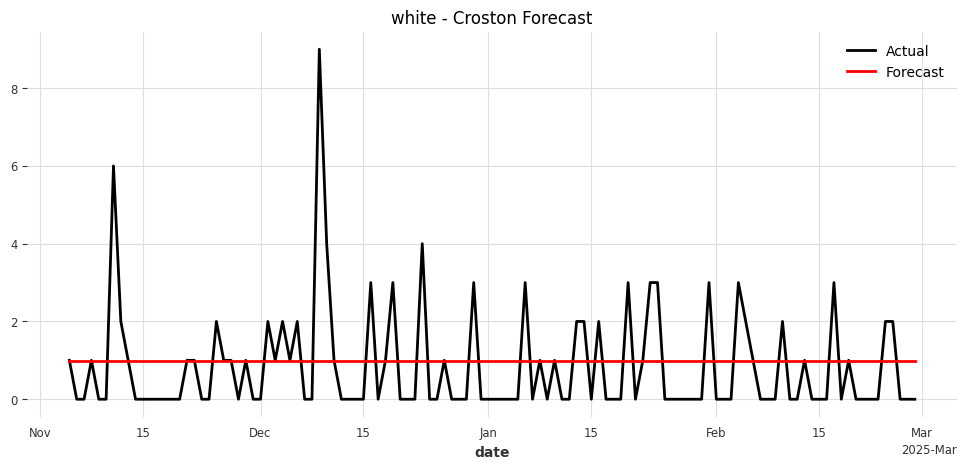

In [29]:
croston_forecast(df, 'white')

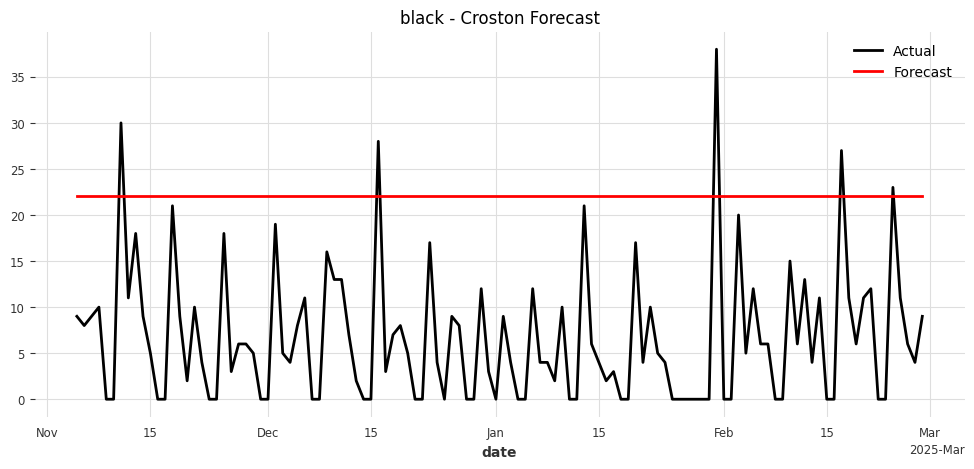

In [30]:
croston_forecast(df, 'black')

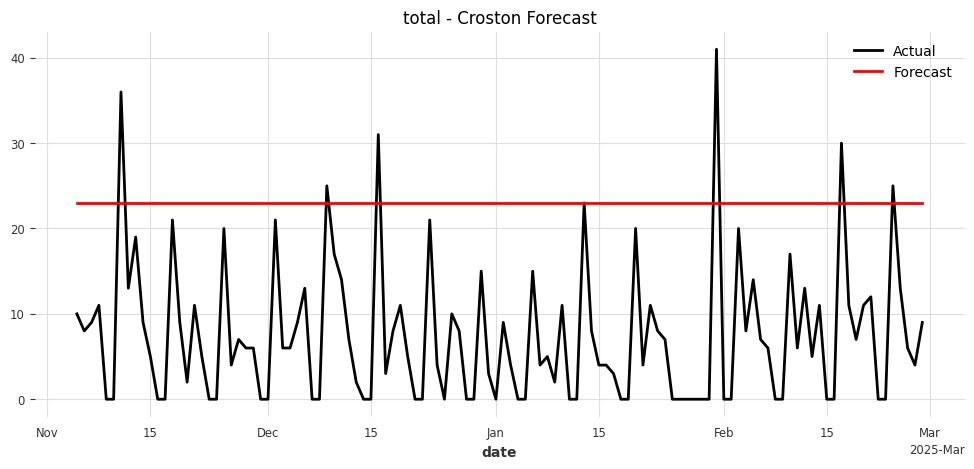

In [31]:
croston_forecast(df, 'total')

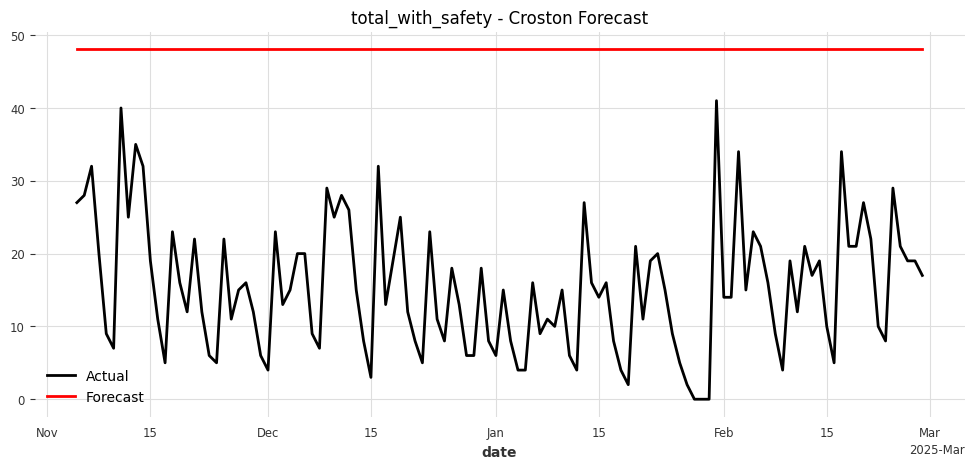

In [32]:
croston_forecast(df, 'total_with_safety')